
# Classification avec un MLP (Multi layers Perceptron)

Dans ce TP, nous utiliserons le jeu de données disponible à l’adresse suivante : [github](https://github.com/renatopp/arff-datasets/blob/master/classification/diabetes.arff) mis à disposition par le **LIAC** (Connectionist Artificial Intelligence Laboratory). L’objectif sera de réaliser une tâche de classification à l’aide d’un perceptron multicouche (MLP), en s’appuyant sur l’implémentation proposée par la bibliothèque scikit-learn.

### Téléchargement du dataset et chargement des données
#### A propos de la data :
**Pima Indians Diabetes dataset**: ce jeu de données contient des informations permettant de classer ou de prédire si des femmes d’origine Pima, âgées de plus de 21 ans, sont diabétiques ou non, c’est-à-dire si elles ont été testées positives ou négatives. Ce jeu de données provient du dépôt Keel et se compose de huit attributs, 768 instances et deux classes. [mdpi.com](https://www.mdpi.com/2227-7390/9/15/1817)

In [2]:
# Here we download the dataset
!curl https://raw.githubusercontent.com/renatopp/arff-datasets/refs/heads/master/classification/diabetes.arff -o diabetes.arff

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 38282  100 38282    0     0  61613      0 --:--:-- --:--:-- --:--:-- 61844


In [3]:
from scipy.io import arff
import pandas as pd

# Load the ARFF file
data, meta = arff.loadarff('diabetes.arff')

# Convert to pandas DataFrame
df_diabete = pd.DataFrame(data)

# If some fields are byte-encoded (common for nominal), decode them:
for column in df_diabete.select_dtypes([object]):
    df_diabete[column] = df_diabete[column].str.decode('utf-8')

# Preview
df_diabete.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,tested_positive
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,tested_negative
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,tested_positive
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,tested_negative
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,tested_positive


## Exploration des données

In [4]:
# Checking if there is some missing values
df_diabete.isna().sum()

preg     0
plas     0
pres     0
skin     0
insu     0
mass     0
pedi     0
age      0
class    0
dtype: int64

In [5]:
# Show data type and useful information
df_diabete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
 8   class   768 non-null    object 
dtypes: float64(8), object(1)
memory usage: 54.1+ KB


In [6]:
# compute some statistics
df_diabete.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


array([[<AxesSubplot:title={'center':'preg'}>,
        <AxesSubplot:title={'center':'plas'}>,
        <AxesSubplot:title={'center':'pres'}>],
       [<AxesSubplot:title={'center':'skin'}>,
        <AxesSubplot:title={'center':'insu'}>,
        <AxesSubplot:title={'center':'mass'}>],
       [<AxesSubplot:title={'center':'pedi'}>,
        <AxesSubplot:title={'center':'age'}>, <AxesSubplot:>]],
      dtype=object)

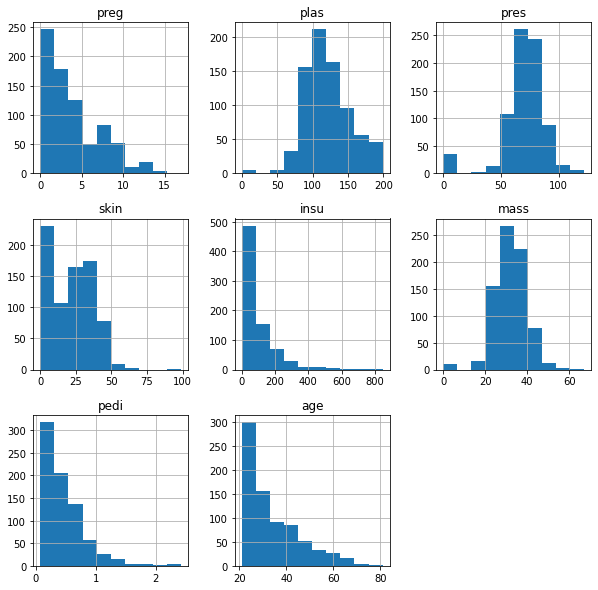

In [7]:
# Data Visualization
from matplotlib import pyplot as plt

df_diabete.hist(figsize=(10,10))

<AxesSubplot:ylabel='class'>

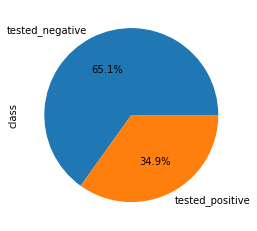

In [8]:
# Plot the proportion of all differents labels in 'class'
df_diabete['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')

## Data preprocessing
Ici ont prépare les données pour l'apprentissage.

In [9]:
# Loading usefull librairies
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
import seaborn as sns

### Encodage des variables catégorielles

In [10]:
# Delete the target variable from the features 
features = df_diabete.drop(columns=['class'])

# Recode the target variable `class`
targets = pd.get_dummies(df_diabete[['class']], drop_first=True) # get_dummies permet de transformer des valeurs qualitatives en variables binaires(one-hot-encoding)
targets

,class_tested_positive
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


### Création des ensembles d'apprentissage et de test
Avant d'effectuer l'apprentissage, il faut diviser notre base de données en 2 :
1. un ensemble d'apprentissage qui servira à entraîner le réseau de neurones
C'est sur cet ensemble qu'on optimise la fonction de perte afin de minimier l'erreur de prédiction.
2. un ensemble de test qui servira à évaluer la qualité de notre apprentissage
Pour séparer notre ensemble de données dans ce sens, la fonction `train_test_split` est bien adaptée. Il suffit de lui indiquer la répartition qu'on souhaite en terme de ratio entre l'ensemble d'apprentissage et celui de test grâce au paramètre `train_size`.

In [11]:
X = features
y = targets.to_numpy().flatten()

# Division en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Afficher les tailles des deux ensembles
print("Taille de l'ensemble d'apprentissage : ", X_train.shape)
print("Taille de l'ensemble de test : ", X_test.shape)

Taille de l'ensemble d'apprentissage :  (614, 8)
Taille de l'ensemble de test :  (154, 8)


### Normalisation des données 
La normalisation des données est bien souvent une étape indispensable pour faciliter l'apprentissage. Cette opération est faite sur l'ensemble d'apprentisage et ensuite appliquer à l'ensemble de test et à chaque échantillon pour lequel on aimerait prédire la classe.

Plusieurs normalisations sont possibles:
- la normalisation centrée réduite
- l'utilisation de la norme L1
- l'utilisation de la norme L2
- ...

Nous utilisons ici la fonction `StandardScaler` dans `sklearn.prepocesing` pour faire une normalisation centrée réduite. On peut également utiliser la fonction `normalize` en passant en paramètre le type de normalisation qu'on souhaite effectuer.

La normalisation ne change absolument pas la taille des échantillons mais leurs valeurs. Pour le vérifier, nous avons afficher les valeurs minimales et maximales des variances et des moyennes avant et après la normalisation centrée réduite. 

In [12]:
# Normalisation des données avant l'apprentissage
scaler = StandardScaler()

# La normalisation se fait uniquement sur les données d'apprentissage
scaler.fit(X_train)
StandardScaler(copy=True , with_mean=True , with_std=True)

# La normalisation ne modifie pas la taille des données mais leurs valeurs
# Afficher les valeurs minimales et maximales de la variance et de la moyenne des données après la normalisations
variances_train = np.std(X_train, 0)
moyennes_train = np.mean(X_train, 0)

print("Avant l'opération de normalisation")
print("Taille de l'ensemble d'apprentissage : ", X_train.shape)

print("Variances des données d'apprentissage : ", [np.round(np.min(variances_train), 3), 
                                                   np.round(np.max(variances_train), 3)] )
print("Moyennes des données d'apprentissage : ", [np.round(np.min(moyennes_train)), 
                                                  np.round(np.max(moyennes_train), 3)])

# Application du modèle de normalisation aux données de test et d'apprentissage
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# La normalisation ne modifie pas la taille des données mais leurs valeurs
variances_train = np.std(X_train, 0)
moyennes_train = np.mean(X_train, 0)

print("\nAprès l'opération de normalisation")
print("Taille de l'ensemble d'apprentissage : ", X_train.shape)

# Afficher les valeurs minimales et maximales de la variance et de la moyenne des données après la normalisations
print("Variances des données d'apprentissage : ", [np.round(np.min(variances_train), 3), 
                                                   np.round(np.max(variances_train), 3)] )
print("Moyennes des données d'apprentissage : ", [np.round(np.min(moyennes_train)), 
                                                  np.round(np.max(moyennes_train), 3)])

Avant l'opération de normalisation
Taille de l'ensemble d'apprentissage :  (614, 8)
Variances des données d'apprentissage :  [0.337, 116.14]
Moyennes des données d'apprentissage :  [0.0, 120.855]

Après l'opération de normalisation
Taille de l'ensemble d'apprentissage :  (614, 8)
Variances des données d'apprentissage :  [1.0, 1.0]
Moyennes des données d'apprentissage :  [-0.0, 0.0]


## Entraînement et évaluation du réseau de neurones multi-perceptron
Pour implémenter notre réseau de neurones, nous utilisons la fonction `MLPClassifier` du module `neural_network` du package ***scikit-learn***. Cette fonction permet de paramétrer les couches cachées (nombre et taille), la fonction d'activation des couches cachées, la fonction d'optimisation, le taux d'apprentissage, le nombre maximum d'itérations, ...

### Entraînement du réseau de neurones 

In [13]:
def display_training_curves(mlp):
    # Inspection visuelle de la fonction de coût pendant l'apprentissage
    fig_loss, axis_loss = plt.subplots(1,1, figsize=(10, 7))
    axis_loss.plot(mlp.loss_curve_)
    axis_loss.set_ylabel("Loss function")
    axis_loss.set_xlabel("Iterations")
    axis_loss.set_title("Learning loss: loss function ==> {}".format(mlp.loss))
    
    if mlp.early_stopping:
        fig_ac, axis_acc = plt.subplots(1,1, figsize=(10, 7))
        axis_acc.plot(mlp.validation_scores_)
        axis_acc.set_ylabel("Validation accuracy")
        axis_acc.set_xlabel("Iterations")
        axis_acc.set_title("Validation accuracy for different training iterations")

Nombre de couches du MLP: 4
Nombre de couches cachées : 2

Output activation function: logistic

Proportion du train utilisée : 1.0



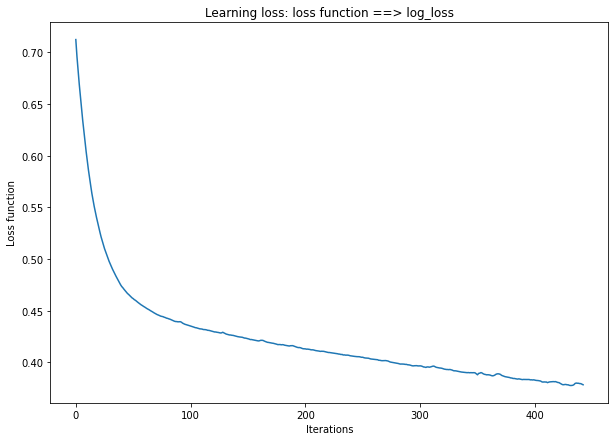

In [14]:
# Utilisation d'un réseau de neurones multi-perceptron pour la classification

# Taille des différentes couches cachés
taille_couches_cachees = (16,10)

# Définition du réseau de neurones
mlp = MLPClassifier(hidden_layer_sizes=taille_couches_cachees,
                    max_iter=3000, 
                    random_state=42)

# Entrainement du réseau défini sur les données d'apprentissage
mlp.fit(X_train, y_train)

# Détails sur les différentes couches
print("Nombre de couches du MLP: {}".format(mlp.n_layers_))
print("Nombre de couches cachées : {}\n".format(len(taille_couches_cachees)))

# Fonction d'activation de sortie
print("Output activation function: {}\n".format(mlp.out_activation_))

# Inspection visuelle de la fonction de coût pendant l'apprentissage
display_training_curves(mlp)
    
# Quelle proportion de la base d'apprentissage a été vue 
print("Proportion du train utilisée : {}\n".format((mlp.t_/len(mlp.loss_curve_))/X_train.shape[0]))



---
# TO DO
--- 
## Modifier les paramètres suivants en vous inspirant de la cellule ci-dessus
- hidden_layer_sizes avec tous les autres paramètres inchangés
- max_iter (une valeur petite < 5) avec tous les autres paramètres inchangés
- batch_size (une valeur à 1 et une valeur égale à la taille de l'ensemble d'apprentissage) avec tous les autres paramètres inchangés
- (bonus) early_stopping à vrai et faux que remarquez vous ?
Note: pour *early_stopping=True*, modifier validation_fraction : 0.1 et 0.2


In [15]:
# Vos differentes implementation ici

## Entrainement d'un MLP pour la suite du TP

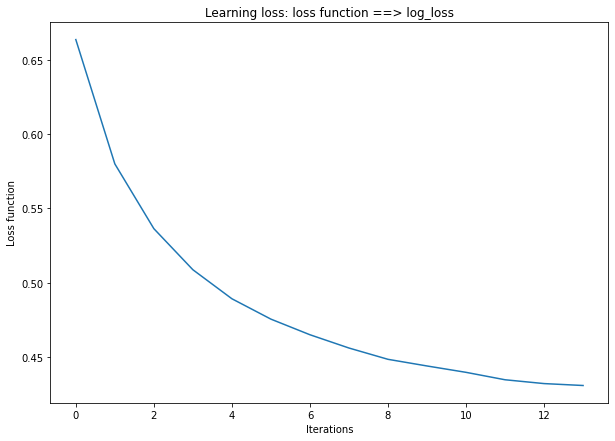

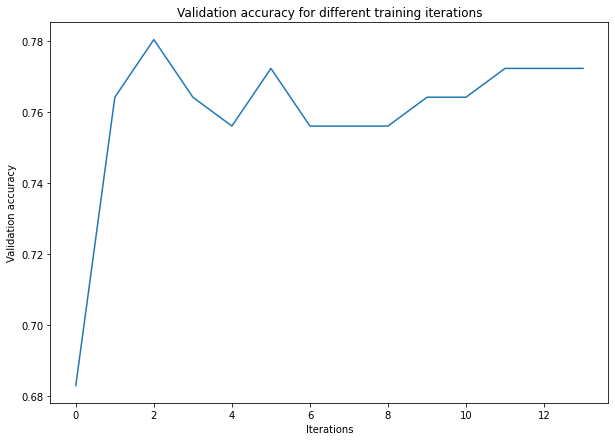

In [16]:
# re-définition du réseau de neurones (pour que tout le monde partage le même réseau)
mlp = MLPClassifier(hidden_layer_sizes=(16, 10),
                    max_iter=3000, 
                    random_state=42, 
                    early_stopping=True,
                    batch_size=10,
                    validation_fraction=0.2)

# Entrainement du réseau défini sur les données d'apprentissage
mlp.fit(X_train, y_train)

# Inspection visuelle de l'entraitement
display_training_curves(mlp)

### Evaluation de l'apprentissage sur les données de test
Pour évaluer la qualité de l'apprentissage, on peut utiliser plusieurs métriques. Dans cet exemple, nous utiliserons :
- la matrice de confusion
- la précision
- le recall
- le score F1

Ces différentes métriques sont déjà implémentées dans le module `metrics` du package ***scikit-learn***.

In [17]:
# Prédictions
y_pred = mlp.predict(X_test)

print("\nMatrice de confusion:")
confusion_matrix(y_test, y_pred)


Matrice de confusion:


array([[79, 20],
       [31, 24]], dtype=int64)

In [18]:
print(mlp.score(X_test, y_test))
predictions_test = mlp.predict(X_test)
print(classification_report(y_test, y_pred))

0.6688311688311688
              precision    recall  f1-score   support

           0       0.72      0.80      0.76        99
           1       0.55      0.44      0.48        55

    accuracy                           0.67       154
   macro avg       0.63      0.62      0.62       154
weighted avg       0.66      0.67      0.66       154



### Validation croisée 
La validation croissée est une approche permettant d'entraîner le modèle plusieurs fois sur des sous-échantillons de la base d'apprentissage. Elle permet de s'assurer que le modèle ne fonctionne pas uniquement dans une seule configuration de l'ensemble d'apprentissage. On peut par la suite sélectionner le modèle qui offre la meilleure précision, le meilleur recall, ...

Nous avons effecutée une validation croissée avec la fonction `cross_val_score` du module `model_selction` du package ***scikit-learn***. Il faut indiquer à cette fonction :
- le nombre de validations croisées qu'on souhaite effectuer avec le paramètre `cv`
- la métrique d'évaluation de la validation croisée avec le paramètre `scoring`

In [19]:
mlp_cross_val_score = cross_val_score(mlp , X_train, y_train, cv=5, scoring="accuracy")
print(mlp_cross_val_score.mean())

0.7296148207383713


**Tiré de TP EEIA 2025**
Tous droits réservés 

